---
# 1. PREPARACIÓN

## 1.1. Carga de librerías

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import optuna

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.datasets import make_classification

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import RandomOverSampler

c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1.2. Carga del CSV y primeras observaciones de los datos

In [3]:
ruta = "loan_data.csv"
datos = pd.read_csv(ruta)

In [4]:
print(datos.shape)
print(f"La cantidad de filas es: {datos.shape[0]}")
print(f"La cantidad de columnas es: {datos.shape[1]}")

(45000, 14)
La cantidad de filas es: 45000
La cantidad de columnas es: 14


In [5]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               45000 non-null  float64
 1   gender            45000 non-null  object 
 2   education         45000 non-null  object 
 3   income            45000 non-null  float64
 4   yrs_exp           45000 non-null  int64  
 5   ownership         45000 non-null  object 
 6   amount            45000 non-null  float64
 7   purpose           44962 non-null  object 
 8   int_rate          45000 non-null  float64
 9   percent_income    45000 non-null  float64
 10  cred_hist_length  45000 non-null  float64
 11  risk_score        45000 non-null  int64  
 12  previous_loans    45000 non-null  object 
 13  loan_status       45000 non-null  int64  
dtypes: float64(6), int64(3), object(5)
memory usage: 4.8+ MB


In [6]:
datos.describe()

,age,income,yrs_exp,amount,int_rate,percent_income,cred_hist_length,risk_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,634.291556,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,366.878869,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,-637.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,77710.000000,1.000000


In [7]:
datos.head()

,age,gender,education,income,yrs_exp,ownership,amount,purpose,int_rate,percent_income,cred_hist_length,risk_score,previous_loans,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


---
# 2. LIMPIEZA DE DATOS

## 2.1. Gestión de valores nulos

In [8]:
print("Número de casillas nulas:")
datos.isnull().sum()

Número de casillas nulas:


age                  0
gender               0
education            0
income               0
yrs_exp              0
ownership            0
amount               0
purpose             38
int_rate             0
percent_income       0
cred_hist_length     0
risk_score           0
previous_loans       0
loan_status          0
dtype: int64

In [9]:
valores_nulos = datos.isnull().sum().sort_values(ascending=False)

# Añadimos "reset_index" para numerar las filas resultantes
ratio_nulos = (valores_nulos / len(datos)).reset_index()
ratio_nulos.columns = ['Caracteristica', 'RatioNulos']
ratio_nulos

,Caracteristica,RatioNulos
0,purpose,0.000844
1,age,0.000000
2,education,0.000000
3,income,0.000000
4,yrs_exp,0.000000
5,gender,0.000000
6,ownership,0.000000
7,amount,0.000000
8,int_rate,0.000000
9,percent_income,0.000000


In [10]:
datos.dropna(subset=['purpose'], inplace=True)

In [11]:
print("Número de casillas nulas después de la eliminación de los valores nulos:")
datos.isnull().sum()

Número de casillas nulas después de la eliminación de los valores nulos:


age                 0
gender              0
education           0
income              0
yrs_exp             0
ownership           0
amount              0
purpose             0
int_rate            0
percent_income      0
cred_hist_length    0
risk_score          0
previous_loans      0
loan_status         0
dtype: int64

## 2.2. Tipos de datos de las columnas

In [12]:
datos.dtypes

age                 float64
gender               object
education            object
income              float64
yrs_exp               int64
ownership            object
amount              float64
purpose              object
int_rate            float64
percent_income      float64
cred_hist_length    float64
risk_score            int64
previous_loans       object
loan_status           int64
dtype: object

## 2.3. Gestión de anomalías (outliers)

In [13]:
columnas = datos.columns.values
print(columnas)

['age' 'gender' 'education' 'income' 'yrs_exp' 'ownership' 'amount'
 'purpose' 'int_rate' 'percent_income' 'cred_hist_length' 'risk_score'
 'previous_loans' 'loan_status']


### 2.3.1 Validación de valores float

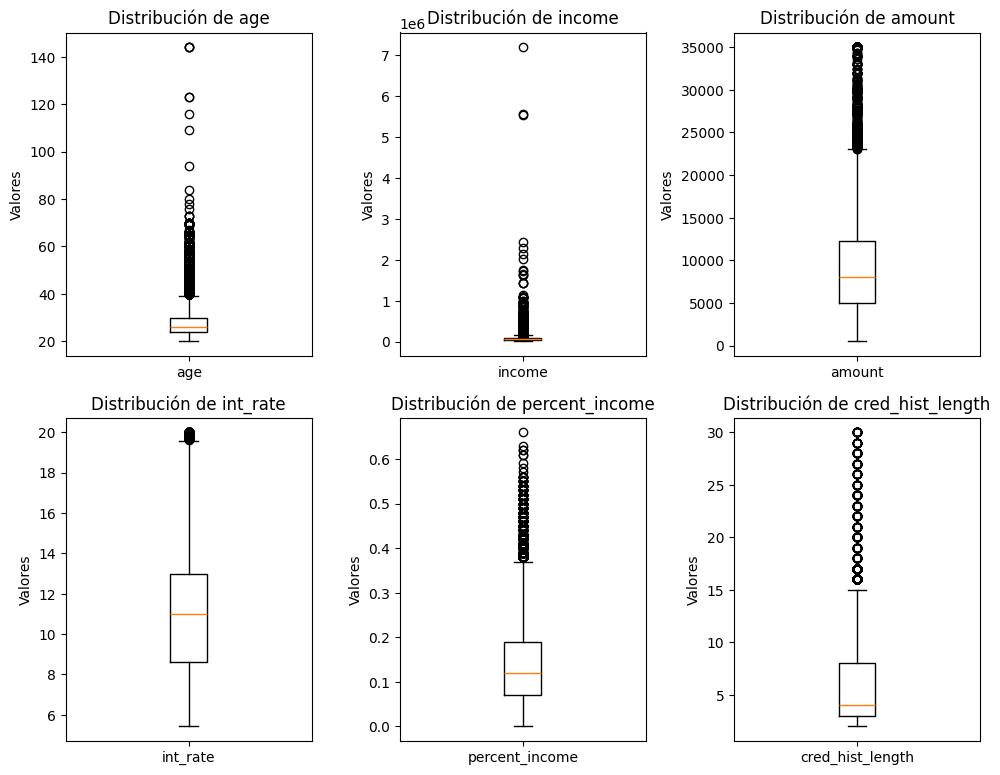

In [14]:
# Valores float
columnas_float = []

for columna_actual in columnas:
    if (datos[columna_actual].dtype == "float64"):
        columnas_float.append(columna_actual)
    

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 8))

axes = axes.flatten()
for i, var in enumerate(columnas_float):
    axes[i].boxplot(datos[var], tick_labels=[var])
    axes[i].set_title(f'Distribución de {var}')
    axes[i].set_ylabel('Valores')

for j in range(len(columnas_float), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [15]:
# Columna 'age'
valor_erroneo = 110

datos_age = datos["age"]
outliers_age = datos_age[datos_age > valor_erroneo]

print(outliers_age)

81       144.0
183      144.0
575      123.0
747      123.0
32297    144.0
37930    116.0
Name: age, dtype: float64


In [16]:
# Eliminamos los datos de clientes con más de 110 años
datos = datos[~datos['age'].isin(outliers_age)]

# Comprobamos que han sido eliminados
datos_age = datos["age"]
outliers_age = datos_age[datos_age > valor_erroneo]
print(outliers_age)

Series([], Name: age, dtype: float64)


### 2.3.2 Validación de valores integer

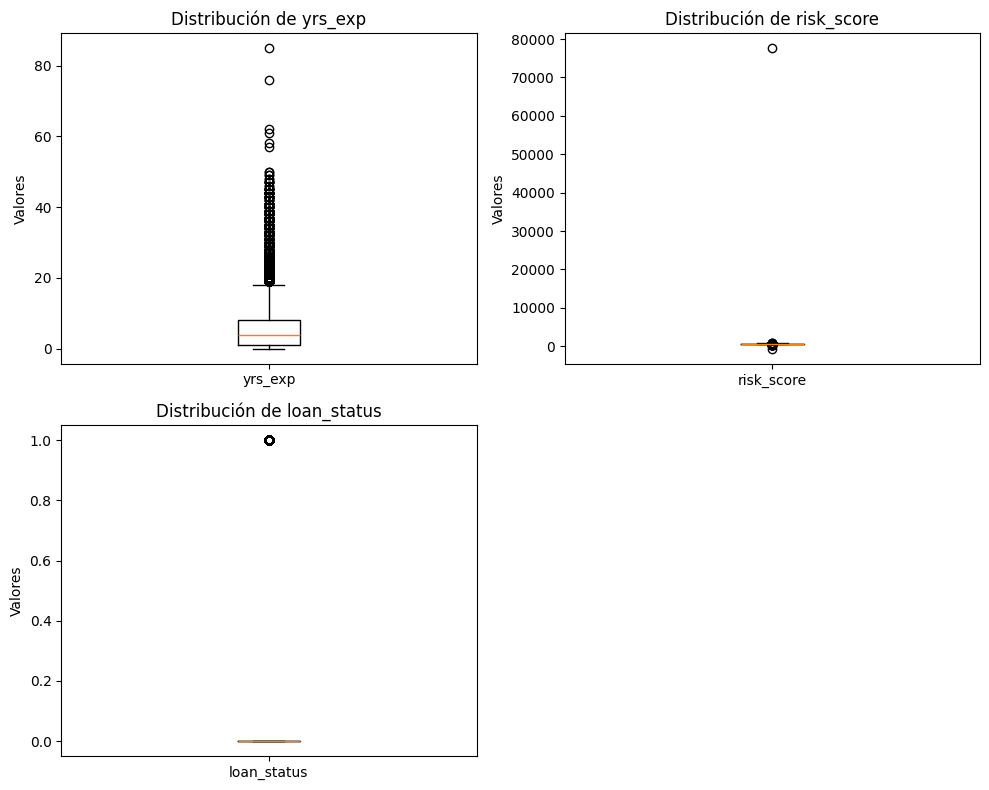

In [17]:
# Valores int
columnas_integer = []

for columna_actual in columnas:
    if (datos[columna_actual].dtype == "int64"):
        columnas_integer.append(columna_actual)
    

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

axes = axes.flatten()
for i, var in enumerate(columnas_integer):
    axes[i].boxplot(datos[var], tick_labels=[var])
    axes[i].set_title(f'Distribución de {var}')
    axes[i].set_ylabel('Valores')

for j in range(len(columnas_integer), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

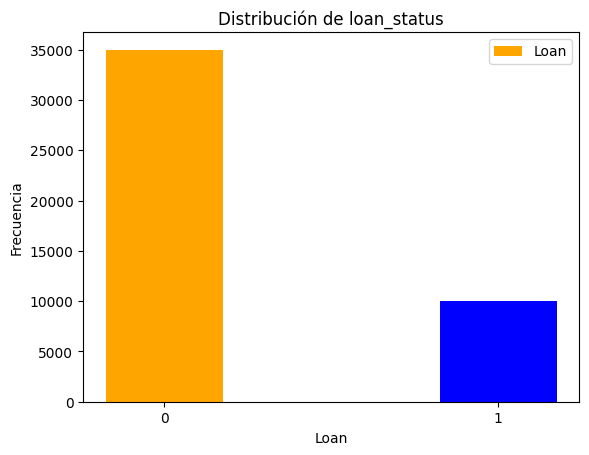

In [18]:
categories = ['0', '1']

# Conteo de frecuencias para cada categoría
valores = datos["loan_status"].value_counts().sort_index()

bar_width = 0.35
x = np.arange(len(categories))

# Graficar las barras con los conteos
plt.bar(x, valores.values, bar_width, color=['orange', 'blue'], label='Loan')

plt.xlabel('Loan')
plt.ylabel('Frecuencia')
plt.title('Distribución de loan_status')
plt.xticks(x, categories)

plt.legend()
plt.show()


In [19]:
# Columna 'yrs_exp'
valor_erroneo = 70

datos_yrs_exp = datos["yrs_exp"]
outliers_yrs_exp = datos_yrs_exp[datos_yrs_exp > valor_erroneo]

print(outliers_yrs_exp)

32416    76
38113    85
Name: yrs_exp, dtype: int64


In [20]:
# Columna 'risk_score'
valor_erroneo = 10000

datos_risk_score = datos["risk_score"]
outliers_risk_score = datos_risk_score[datos_risk_score > valor_erroneo]

print(outliers_risk_score)

9793    77710
Name: risk_score, dtype: int64


In [21]:
# Eliminamos los datos de clientes con más de 70 años de experiencia
datos = datos[~datos['yrs_exp'].isin(outliers_yrs_exp)]

# Eliminamos los datos del cliente con un risk_score de 70000
datos = datos[~datos['risk_score'].isin(outliers_risk_score)]

In [22]:
# Columna 'yrs_exp'
datos_yrs_exp = datos["yrs_exp"]
outliers_yrs_exp = datos_yrs_exp[datos_yrs_exp > 70]
print(outliers_yrs_exp)

# Columna 'risk_score'
datos_risk_score = datos["risk_score"]
outliers_risk_score = datos_risk_score[datos_risk_score > 10000]
print(outliers_risk_score)

Series([], Name: yrs_exp, dtype: int64)
Series([], Name: risk_score, dtype: int64)


### 2.3.3 Validación de valores object

In [23]:
columnas_objeto = datos.select_dtypes(include=['object']).columns

lista_columnas_objeto = list(columnas_objeto)
print(lista_columnas_objeto)

['gender', 'education', 'ownership', 'purpose', 'previous_loans']


In [24]:
for columna_actual in lista_columnas_objeto:
    conteo = datos.groupby(columna_actual).size()
    print(f"{conteo}\n")

gender
femal         1
female    20133
male      24819
dtype: int64

education
Associate      12017
Bachelor       13381
Doctorate        621
High School    11959
Master          6975
dtype: int64

ownership
MORTGAGE    18477
OTHER         117
OWN          2950
OWN             1
RENT        23408
dtype: int64

purpose
DEBTCONSOLIDATION    7132
EDUCATION            9143
HOMEIMPROVEMENT      4779
MEDICAL              8541
PERSONAL             7545
VENTURE              7813
dtype: int64

previous_loans
No     22103
Yes    22850
dtype: int64



In [25]:
# Corregimos el valor 'femal' a 'female'
datos['gender'] = datos['gender'].replace('femal', 'female')

# Verificamos que se haya corregido el valor incorrecto
print(datos['gender'].value_counts())

gender
male      24819
female    20134
Name: count, dtype: int64


In [26]:
# Limpiamos los valores de la columna 'ownership'
datos['ownership'] = datos['ownership'].str.strip()

# Verificamos que se haya realizado la limpieza correctamente
print(datos['ownership'].value_counts())

ownership
RENT        23408
MORTGAGE    18477
OWN          2951
OTHER         117
Name: count, dtype: int64


---
# 3. Ingeniería de características
## 3.1. Codificación de variables categóricas

In [27]:
datos.head()

,age,gender,education,income,yrs_exp,ownership,amount,purpose,int_rate,percent_income,cred_hist_length,risk_score,previous_loans,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [28]:
datos['gender'] = datos['gender'].replace(["male", "female"], [0, 1])
datos['education'] = datos['education'].replace(["High School", "Associate", "Bachelor", "Master", "Doctorate"], [0, 1, 2, 3, 4])

datos = pd.get_dummies(datos, columns=['ownership'], prefix='ownership')
datos = pd.get_dummies(datos, columns=['purpose'], prefix='purpose')
datos = pd.get_dummies(datos, columns=['previous_loans'], prefix='previous_loans')

C:\Users\davil\AppData\Local\Temp\ipykernel_12568\737500548.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  datos['gender'] = datos['gender'].replace(["male", "female"], [0, 1])
C:\Users\davil\AppData\Local\Temp\ipykernel_12568\737500548.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  datos['education'] = datos['education'].replace(["High School", "Associate", "Bachelor", "Master", "Doctorate"], [0, 1, 2, 3, 4])


In [29]:
datos.head()

,age,gender,education,income,yrs_exp,amount,int_rate,percent_income,cred_hist_length,risk_score,...,ownership_OWN,ownership_RENT,purpose_DEBTCONSOLIDATION,purpose_EDUCATION,purpose_HOMEIMPROVEMENT,purpose_MEDICAL,purpose_PERSONAL,purpose_VENTURE,previous_loans_No,previous_loans_Yes
0,22.0,1,3,71948.0,0,35000.0,16.02,0.49,3.0,561,...,False,True,False,False,False,False,True,False,True,False
1,21.0,1,0,12282.0,0,1000.0,11.14,0.08,2.0,504,...,True,False,False,True,False,False,False,False,False,True
2,25.0,1,0,12438.0,3,5500.0,12.87,0.44,3.0,635,...,False,False,False,False,False,True,False,False,True,False
3,23.0,1,2,79753.0,0,35000.0,15.23,0.44,2.0,675,...,False,True,False,False,False,True,False,False,True,False
4,24.0,0,3,66135.0,1,35000.0,14.27,0.53,4.0,586,...,False,True,False,False,False,True,False,False,True,False


In [30]:
datos.drop('previous_loans_No', axis=1, inplace=True)

datos.dtypes

age                          float64
gender                         int64
education                      int64
income                       float64
yrs_exp                        int64
amount                       float64
int_rate                     float64
percent_income               float64
cred_hist_length             float64
risk_score                     int64
loan_status                    int64
ownership_MORTGAGE              bool
ownership_OTHER                 bool
ownership_OWN                   bool
ownership_RENT                  bool
purpose_DEBTCONSOLIDATION       bool
purpose_EDUCATION               bool
purpose_HOMEIMPROVEMENT         bool
purpose_MEDICAL                 bool
purpose_PERSONAL                bool
purpose_VENTURE                 bool
previous_loans_Yes              bool
dtype: object

---
# MODELO 1. PREDICTOR DE: LOAN STATUS

### 3.2. Selección de características

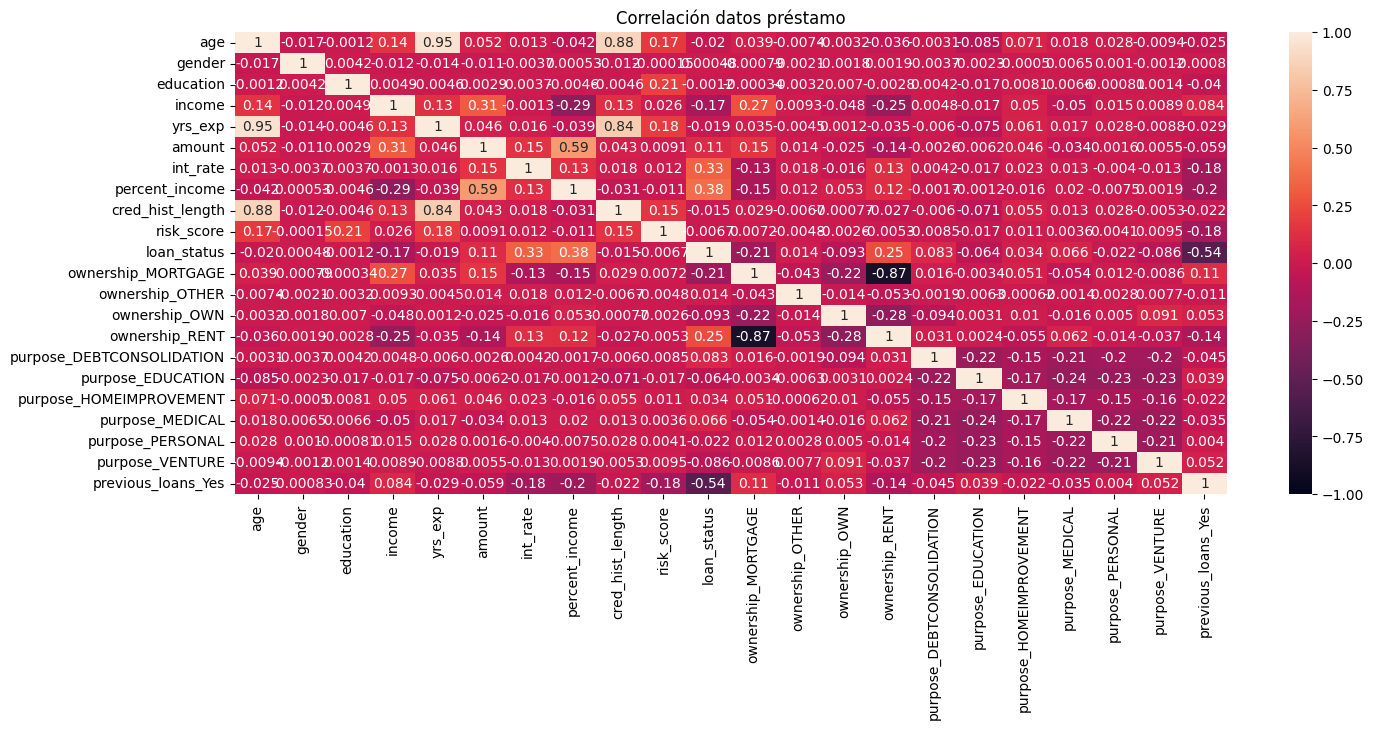

In [31]:
plt.figure(figsize=(16, 6))
heatmap = sns.heatmap(datos.corr(), vmin=-1, vmax=1, annot=True)
heatmap.set_title('Correlación datos préstamo')

plt.show()

In [32]:
valor_objetivo = "loan_status"
print(datos.shape)
print(datos[valor_objetivo].describe())
datos.describe()

(44953, 22)
count    44953.000000
mean         0.221743
std          0.415424
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: loan_status, dtype: float64


,age,gender,education,income,yrs_exp,amount,int_rate,percent_income,cred_hist_length,risk_score,loan_status
count,44953.000000,44953.000000,44953.000000,4.495300e+04,44953.000000,44953.000000,44953.000000,44953.000000,44953.000000,44953.000000,44953.000000
mean,27.747781,0.447890,1.383400,7.992440e+04,5.394101,9582.898049,11.005161,0.139700,5.866194,632.562610,0.221743
std,5.903090,0.497283,1.077826,6.333701e+04,5.919362,6314.384137,2.979064,0.087182,3.876819,50.749077,0.415424
min,20.000000,0.000000,0.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,-637.000000,0.000000
25%,24.000000,0.000000,0.000000,4.721900e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,0.000000,1.000000,6.704900e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,1.000000,2.000000,9.578900e+04,8.000000,12231.000000,12.990000,0.190000,8.000000,670.000000,0.000000
max,84.000000,1.000000,4.000000,2.448661e+06,62.000000,35000.000000,20.000000,0.660000,30.000000,784.000000,1.000000


In [33]:
columnas_relevantes = ['previous_loans_Yes', 'percent_income', 'int_rate', 'ownership_RENT', 'ownership_MORTGAGE']
datos_loan_status = datos[columnas_relevantes + [valor_objetivo]]
datos_loan_status.head()

,previous_loans_Yes,percent_income,int_rate,ownership_RENT,ownership_MORTGAGE,loan_status
0,False,0.49,16.02,True,False,1
1,True,0.08,11.14,False,False,0
2,False,0.44,12.87,False,True,1
3,False,0.44,15.23,True,False,1
4,False,0.53,14.27,True,False,1


## `QUITAR`

### 3.3. Escalado

In [34]:
"""
datos_loan_status["percent_income"] = (
    datos_loan_status["percent_income"] - datos_loan_status["percent_income"].mean()
) / datos_loan_status["percent_income"].std()

datos_loan_status["int_rate"] = (
    datos_loan_status["int_rate"] - datos_loan_status["int_rate"].mean()
) / datos_loan_status["int_rate"].std()
"""

'\ndatos_loan_status["percent_income"] = (\n    datos_loan_status["percent_income"] - datos_loan_status["percent_income"].mean()\n) / datos_loan_status["percent_income"].std()\n\ndatos_loan_status["int_rate"] = (\n    datos_loan_status["int_rate"] - datos_loan_status["int_rate"].mean()\n) / datos_loan_status["int_rate"].std()\n'

In [35]:
datos_loan_status.head()

,previous_loans_Yes,percent_income,int_rate,ownership_RENT,ownership_MORTGAGE,loan_status
0,False,0.49,16.02,True,False,1
1,True,0.08,11.14,False,False,0
2,False,0.44,12.87,False,True,1
3,False,0.44,15.23,True,False,1
4,False,0.53,14.27,True,False,1


## `HASTA AQUÍ`

## 5. Desarrollo de un modelo supervisado de clasificación

### 5.2. Preparación de los conjuntos train y test

In [36]:
X = datos_loan_status.drop('loan_status',axis=1)
y = datos_loan_status['loan_status']

### Balanceo de clases

In [37]:
# Paso 1: Combinar X e y para facilitar el muestreo
from sklearn.utils import resample


df = pd.concat([X, y], axis=1)

# Paso 2: Separar clases
minority_class = df[y.name].value_counts().idxmin()
majority_class = df[y.name].value_counts().idxmax()

df_minority = df[df[y.name] == minority_class]
df_majority = df[df[y.name] == majority_class]

# Paso 3: Hacer oversampling de la clase minoritaria
df_minority_upsampled = resample(
    df_minority,
    replace=True,              # sample with replacement
    n_samples=len(df_majority),# igualar cantidad a la clase mayoritaria
    random_state=42
)

# Paso 4: Combinar datos balanceados
df_upsampled = pd.concat([df_majority, df_minority_upsampled])

# Paso 5: Separar de nuevo en X e y
X_bal = df_upsampled.drop(columns=y.name)
y_bal = df_upsampled[y.name]

In [38]:
#X = X_bal
#y = y_bal

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

### 5.3. Entrenamiento y métricas de validación del modelo

In [39]:
def train_validation(model):
    model.fit(X_train, y_train.astype(int))
    y_pred = model.predict(X_test)
    conf_matrix = confusion_matrix(y_pred, y_test)

    print(classification_report(y_pred, y_test.astype(int)))
    print("score_test = ", model.score(X_test, y_test.astype(int)))
    print("score_train = ", model.score(X_train, y_train.astype(int)))

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No préstamo", "Préstamo"],
        yticklabels=["No préstamo", "Préstamo"],
    )
    plt.title("Matriz de Confusión")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()

#### 5.3.1 Tuning de hiperparámetros

In [40]:
# Originalmente los hiperparámetros no eran estos, pero los he cambiado para que tarde menos cada vez que ejecuto el NoteBook.

def objective(trial):
    max_depth = trial.suggest_int('max_depth', 3, 7)
    learning_rate = trial.suggest_float('learning_rate', 0.005, 0.7, log=True)
    n_estimators = trial.suggest_int('n_estimators', 100, 300)
    gamma = trial.suggest_float('gamma', 0.3, 0.7)

    model = XGBClassifier(max_depth=max_depth, learning_rate=learning_rate, n_estimators=n_estimators, gamma=gamma)
    return cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()

# Crear el studio y ver los resultados
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)
print("Mejores hiperparámetros:", study.best_params)

[I 2025-05-19 18:29:21,193] A new study created in memory with name: no-name-d647d25e-fd22-4f91-985e-1296f8b3b205
[I 2025-05-19 18:29:23,456] Trial 0 finished with value: 0.8993457210154409 and parameters: {'max_depth': 6, 'learning_rate': 0.011548392011161479, 'n_estimators': 180, 'gamma': 0.3668678542474552}. Best is trial 0 with value: 0.8993457210154409.
[I 2025-05-19 18:29:24,928] Trial 1 finished with value: 0.9002093692750588 and parameters: {'max_depth': 3, 'learning_rate': 0.322284399189705, 'n_estimators': 271, 'gamma': 0.583201584130207}. Best is trial 1 with value: 0.9002093692750588.
[I 2025-05-19 18:29:25,821] Trial 2 finished with value: 0.8991363517403821 and parameters: {'max_depth': 7, 'learning_rate': 0.3506913632065384, 'n_estimators': 129, 'gamma': 0.6749439774800206}. Best is trial 1 with value: 0.9002093692750588.
[I 2025-05-19 18:29:26,646] Trial 3 finished with value: 0.9003140539125882 and parameters: {'max_depth': 3, 'learning_rate': 0.3448624605918958, 'n_es

Mejores hiperparámetros: {'max_depth': 4, 'learning_rate': 0.1403889111188745, 'n_estimators': 272, 'gamma': 0.3271593532952064}


              precision    recall  f1-score   support

           0       0.97      0.91      0.94      5580
           1       0.67      0.85      0.75      1163

    accuracy                           0.90      6743
   macro avg       0.82      0.88      0.85      6743
weighted avg       0.92      0.90      0.91      6743

score_test =  0.9039003410944684
score_train =  0.9024077466631771


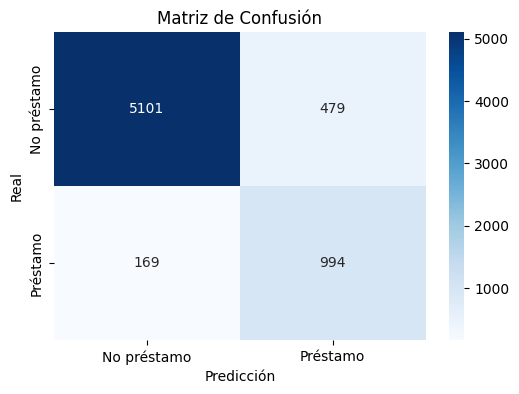

In [41]:
# Modelo: XGBClassifier
model = XGBClassifier(
    max_depth=study.best_params['max_depth'],
    learning_rate=study.best_params['learning_rate'],
    n_estimators=study.best_params['n_estimators'],
    gamma=study.best_params['gamma']
)

model.fit(X_train, y_train)
train_validation(model)

## 6. Predicción ficticia para la prueba del modelo

In [42]:
datos_cliente_prueba = {
    'previous_loans_Yes': [False],
    'percent_income': [2.74],
    'int_rate': [0.89],
    'ownership_RENT': [True],
    'ownership_MORTGAGE': [False]
}

datos_cliente_prueba2 = {
    'previous_loans_Yes': [True],
    'percent_income': [1.79],
    'int_rate': [0.13],
    'ownership_RENT': [True],
    'ownership_MORTGAGE': [True]
}

datos_prueba = pd.DataFrame(datos_cliente_prueba)
datos_prueba2 = pd.DataFrame(datos_cliente_prueba2)

datos_prueba3 = datos[1234:1235]
datos_prueba3_relevantes = datos_prueba3[columnas_relevantes]
resultado_original = "Sí" if datos_prueba3["loan_status"].values == [1] else "No"

prediccion = model.predict(datos_prueba)
prediccion2 = model.predict(datos_prueba2)
prediccion3 = model.predict(datos_prueba3_relevantes)

prediccion = "Sí" if prediccion == 1 else "No"
prediccion2 = "Sí" if prediccion == 1 else "No"
prediccion3 = "Sí" if prediccion == 1 else "No"

print(f"¿Se aprueba el préstamo del cliente 1?: {prediccion}")
print(f"¿Se aprueba el préstamo del cliente 2?: {prediccion2}")
print(f"¿Se aprueba el préstamo del cliente 3?: {prediccion3}. Resultado original: {resultado_original}")

¿Se aprueba el préstamo del cliente 1?: Sí
¿Se aprueba el préstamo del cliente 2?: No
¿Se aprueba el préstamo del cliente 3?: No. Resultado original: No


---
# Guardar información

In [43]:
df.head()

,previous_loans_Yes,percent_income,int_rate,ownership_RENT,ownership_MORTGAGE,loan_status
0,False,0.49,16.02,True,False,1
1,True,0.08,11.14,False,False,0
2,False,0.44,12.87,False,True,1
3,False,0.44,15.23,True,False,1
4,False,0.53,14.27,True,False,1


In [44]:
df.dtypes

previous_loans_Yes       bool
percent_income        float64
int_rate              float64
ownership_RENT           bool
ownership_MORTGAGE       bool
loan_status             int64
dtype: object

In [45]:
import joblib

#joblib.dump(model, 'modelo.pkl')
"""
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(encoder, 'encoder.pkl')
"""

"\njoblib.dump(scaler, 'scaler.pkl')\njoblib.dump(encoder, 'encoder.pkl')\n"

In [46]:
"""
objetos = {
    'modelo': model,
    'scaler': scaler,
    'encoder': encoder
}
joblib.dump(objetos, 'modelo_completo.pkl')
"""

"\nobjetos = {\n    'modelo': model,\n    'scaler': scaler,\n    'encoder': encoder\n}\njoblib.dump(objetos, 'modelo_completo.pkl')\n"